Total valid 10-cycle blocks to process: 249

--- Final Averaged Power Analysis ---
Average RMS Voltage: 229.81 V
Average RMS Current: 10.61 A
Average Frequency: 49.9999 Hz
Funamental Active Power (P): 2110.88 W
Funamental Reactive Power (Q): -1218.58 VAR
Funamental Apparent Power (S): 2437.36 VA
Displacement Power Factor: 0.8660
Phi angle: -29.9973°

Theoretical Target Power: 2110.94 W

Total RMS Voltage: 232.80 V
Total RMS Current: 11.19 A
Total Active Power (P): 2199.56 W
Total Reactive Power (Q): 1393.83 VAR
Total Apparent Power (S): 2604.00 VA
Total Power Factor: 0.8447

Voltage THD: 16.05%
Current THD: 33.34%


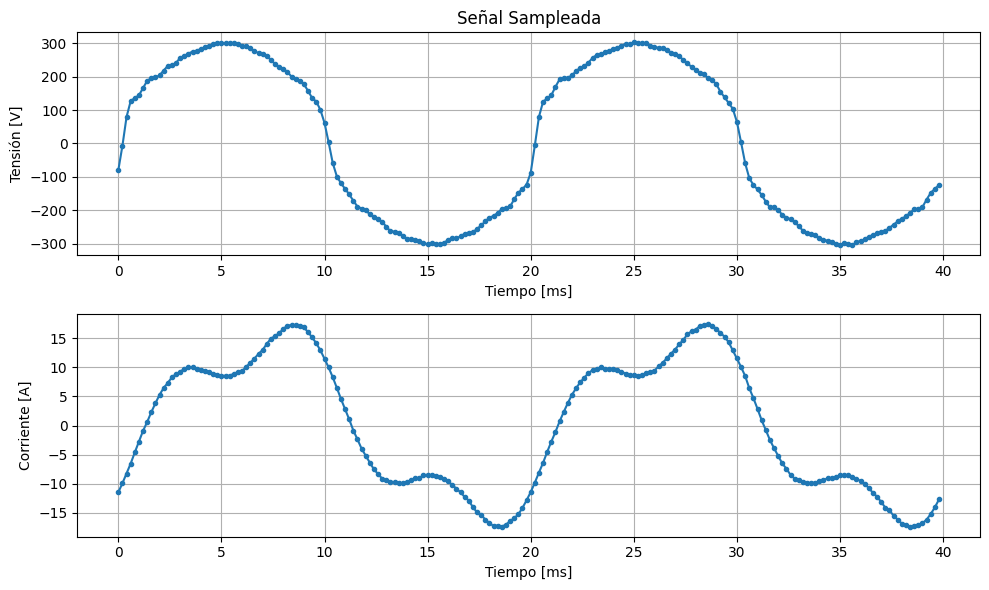

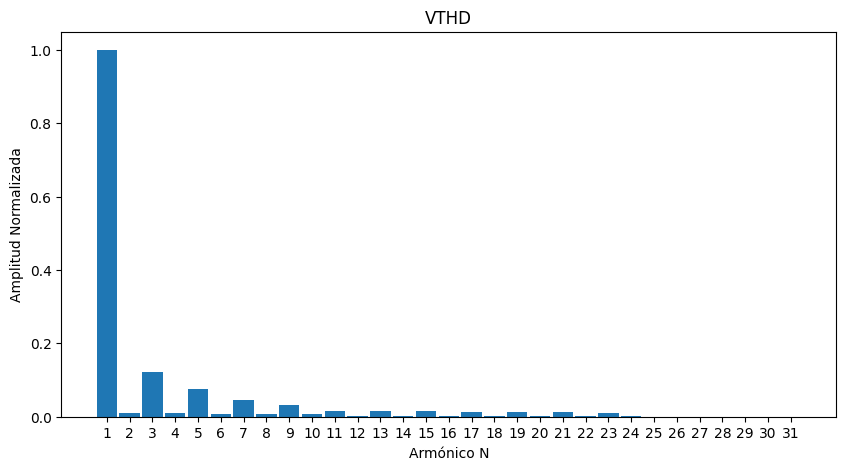

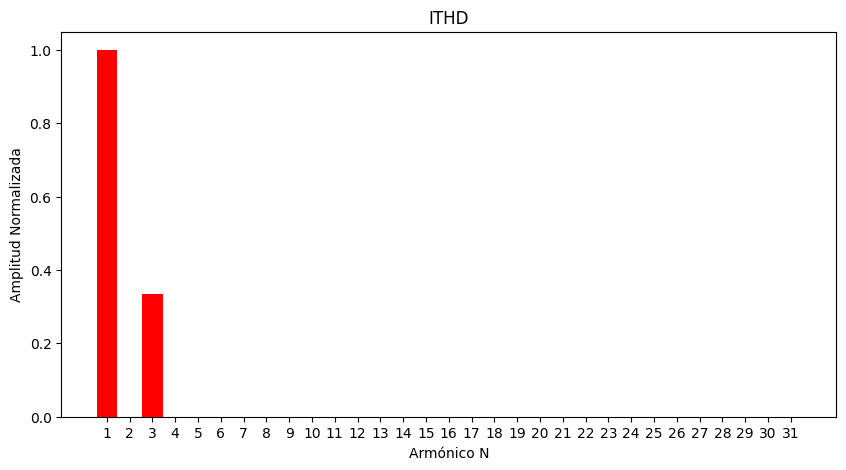

In [ ]:
import numpy as np
from scipy.signal import butter, lfilter, filtfilt, windows

fs_analog = 100000.0
duration = 5.0
t_analog = np.arange(0, duration, 1/fs_analog)
f0 = 50.0
phase_lag = np.pi / 6

#Make "real" signal
Vanalog_harm_amp = [3,40,3,25,2,15,2,10,2,5,1,5,1,5,1,4,1,4,1,4,1,3,1]

v_analog = 10.0 + 325.0 * np.sin(2 * np.pi * f0 * t_analog)
for(i, amp) in enumerate(Vanalog_harm_amp):
    v_analog += amp * np.sin(2 * np.pi * (i+2) * f0 * t_analog)
i_analog = 2.0 + 15.0 * np.sin(2 * np.pi * f0 * t_analog - phase_lag) + 5.0 * np.sin(2 * np.pi * 3 * f0 * t_analog - 0.5)

v_analog += np.random.normal(0, 10.0, len(t_analog))
i_analog += np.random.normal(0, 0.5, len(t_analog))

# Simulate sampling by decimating "real" signal
fs_digital = 5000.0
decimation_factor = int(fs_analog / fs_digital)

# Filter input signals
def anti_alias_filter(signal, cutoff_hz, fs):
    nyq = 0.5 * fs
    b, a = butter(4, cutoff_hz / nyq, btype='low')
    return lfilter(b, a, signal)

v_analog_filt = anti_alias_filter(v_analog, 2000.0, fs_analog)
i_analog_filt = anti_alias_filter(i_analog, 2000.0, fs_analog)

v_sampled = v_analog_filt[::decimation_factor]
i_sampled = i_analog_filt[::decimation_factor]

#Remove DC components from components offset
def high_pass_filter(signal, cutoff_hz, fs):
    nyq = 0.5 * fs
    b, a = butter(2, cutoff_hz / nyq, btype='high')
    return filtfilt(b, a, signal)

v_dig = high_pass_filter(v_sampled, 1.0, fs_digital)
i_dig = high_pass_filter(i_sampled, 1.0, fs_digital)

# ==========================================
# 4. Robust Zero-Crossing Detection
# ==========================================
def find_all_crossings(signal, fs):
    crossings_t = []
    crossings_idx = []

    # Start at index 1 to allow checking i-1
    for i in range(1, len(signal)):
        # Positive-going zero crossing
        if signal[i-1] <= 0 and signal[i] > 0:
            # Proportional interpolation (safer than slope math)
            y1 = abs(signal[i-1])
            y2 = signal[i]
            fraction = y1 / (y1 + y2)

            t_cross = ((i - 1) / fs) + (fraction * (1.0 / fs))

            crossings_t.append(t_cross)
            crossings_idx.append(i) # Snap to the nearest index for slicing

    return crossings_t, crossings_idx

# Get all crossings based on the voltage signal
t_crossings, idx_crossings = find_all_crossings(v_dig, fs_digital)

# DISCARD the first crossings to let all digital/analog filters settle
t_crossings = t_crossings[5:]
idx_crossings = idx_crossings[5:]

# ==========================================
# 5. Goertzel Function
# ==========================================
def goertzel_windowed(signal, fs, target_freq, coherent_gain):
    N = len(signal)
    omega = 2.0 * np.pi * target_freq / fs
    coeff = 2.0 * np.cos(omega)

    s_prev1 = 0.0
    s_prev2 = 0.0

    for x in signal:
        s = x + coeff * s_prev1 - s_prev2
        s_prev2 = s_prev1
        s_prev1 = s

    real_part = s_prev1 - s_prev2 * np.cos(omega)
    imag_part = -s_prev2 * np.sin(omega)

    return complex(real_part, imag_part) * (2.0 / (N * coherent_gain))

# ==========================================
# 6. Continuous Block Processing Loop
# ==========================================
# We need at least 11 crossings to form one 10-cycle block
total_blocks = (len(t_crossings) - 1) // 10

print(f"Total valid 10-cycle blocks to process: {total_blocks}\n")

v_fund_abs = []
i_fund_abs = []
active_powers = []
reactive_powers = []
apparent_powers = []
phi_angles = []
frequencies = []
V_hamonics = [[] for _ in range(31)]
I_hamonics = [[] for _ in range(31)]

for j in range(total_blocks):
    # Extract times and indices for exactly 10 cycles
    t_start = t_crossings[j*10]
    t_end = t_crossings[j*10+10]
    start_idx = idx_crossings[j*10]
    end_idx = idx_crossings[j*10+10]

    # Precise frequency for this specific block
    f_est = 10.0 / (t_end - t_start)
    frequencies.append(f_est)

    # Slice the data
    v_block = v_dig[start_idx:end_idx]
    i_block = i_dig[start_idx:end_idx]

    # Apply Hann Window
    win = windows.hann(len(v_block))
    coherent_gain = np.mean(win)
    v_block_win = v_block * win
    i_block_win = i_block * win

    # Extract Fundamental Phasors (Harmonic 1)
    v_fund = goertzel_windowed(v_block_win, fs_digital, f_est, coherent_gain)
    i_fund = goertzel_windowed(i_block_win, fs_digital, f_est, coherent_gain)
    v_fund_abs.append(np.abs(v_fund))
    i_fund_abs.append(np.abs(i_fund))

    # Calculate Power for this block
    p_active = 0.5 * np.real(v_fund * np.conjugate(i_fund))
    p_reactive = 0.5 * np.imag(v_fund * np.conjugate(i_fund))
    p_apparent = 0.5 * np.abs(v_fund) * np.abs(i_fund)
    phi = np.angle(v_fund * np.conjugate(i_fund))

    active_powers.append(p_active)
    reactive_powers.append(p_reactive)
    apparent_powers.append(p_apparent)
    phi_angles.append(phi)

    V_hamonics[0].append(np.abs(v_fund))
    I_hamonics[0].append(np.abs(i_fund))

    for i in range(30):
        V_hamonics[i+1].append(np.abs(goertzel_windowed(v_block_win, fs_digital, f_est*(i+2), coherent_gain)))
        I_hamonics[i+1].append(np.abs(goertzel_windowed(i_block_win, fs_digital, f_est*(i+2), coherent_gain)))

# ==========================================
# 7. Final Averaged Results
# ==========================================
avg_vrms = np.mean(np.abs(v_fund_abs))/np.sqrt(2)
avg_irms = np.mean(np.abs(i_fund_abs))/np.sqrt(2)
avg_frequency = np.mean(frequencies)
avg_active_power = np.mean(active_powers)
avg_reactive_power = np.mean(reactive_powers)
avg_apparent_power = np.mean(apparent_powers)
avg_power_factor = avg_active_power / avg_apparent_power

print("--- Final Averaged Power Analysis ---")
print(f"Average RMS Voltage: {avg_vrms:.2f} V")
print(f"Average RMS Current: {avg_irms:.2f} A")
print(f"Average Frequency: {avg_frequency:.4f} Hz")
print(f"Funamental Active Power (P): {avg_active_power:.2f} W")
print(f"Funamental Reactive Power (Q): {avg_reactive_power:.2f} VAR")
print(f"Funamental Apparent Power (S): {avg_apparent_power:.2f} VA")
print(f"Displacement Power Factor: {avg_power_factor:.4f}")
print(f"Phi angle: {np.mean(phi_angles)* 180 / np.pi:.4f}°")  # phi = phase_v - phase_i

print(f"\nTheoretical Target Power: {0.5 * 325.0 * 15.0 * np.cos(phase_lag):.2f} W")
print("")
Vrms = np.sqrt(np.mean(v_dig**2)) # estoy hay que hacerlo por bloques,
Irms = np.sqrt(np.mean(i_dig**2)) # por ahora queda aca por paja
P = np.mean(v_dig * i_dig)
S = Vrms * Irms
TPF = P / S
print(f"Total RMS Voltage: {Vrms:.2f} V")
print(f"Total RMS Current: {Irms:.2f} A")
print(f"Total Active Power (P): {P:.2f} W")
print(f"Total Reactive Power (Q): {(S**2 - P**2)**0.5:.2f} VAR")
print(f"Total Apparent Power (S): {S:.2f} VA")
print(f"Total Power Factor: {TPF:.4f}")
print("")

V_hamonics_avg = np.array([np.mean(subarr) for subarr in V_hamonics])
I_hamonics_avg = np.array([np.mean(subarr) for subarr in I_hamonics])


# lo calculo con goertzel, otra opcion es integrar toda la potencia, ya que la potencia fundamental ya la tenemos
VTHD = 100 * np.sqrt(np.sum(V_hamonics_avg[1:]**2)) / V_hamonics_avg[0]
ITHD = 100 * np.sqrt(np.sum(I_hamonics_avg[1:]**2)) / I_hamonics_avg[0]
print(f"Voltage THD: {VTHD:.2f}%")
print(f"Current THD: {ITHD:.2f}%")

# ploteo
V_hamonics_avg = V_hamonics_avg / V_hamonics_avg[0]
I_hamonics_avg = I_hamonics_avg / I_hamonics_avg[0]
harmonic_frequencies = np.arange(1, len(V_hamonics)+1)

import matplotlib.pyplot as plt
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))
axs[0].set_title("Señal Sampleada")
t = np.arange(0, 200) / fs_digital
axs[0].plot(t*1000,v_dig[3000:3200], marker='.')
axs[0].grid(True)
axs[1].plot(t*1000,i_dig[3000:3200], marker='.')
axs[1].grid(True)
axs[0].set_xlabel('Tiempo [ms]')
axs[0].set_ylabel('Tensión [V]')
axs[1].set_xlabel('Tiempo [ms]')
axs[1].set_ylabel('Corriente [A]')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))
plt.title("VTHD")
plt.bar(harmonic_frequencies, V_hamonics_avg, width=0.9)
plt.xticks(harmonic_frequencies)
plt.xlabel('Armónico N')
plt.ylabel('Amplitud Normalizada')
plt.show()

plt.figure(figsize=(10,5))
plt.title("ITHD")
plt.bar(harmonic_frequencies, I_hamonics_avg, width=0.9, color='r')
plt.xticks(harmonic_frequencies)
plt.xlabel('Armónico N')
plt.ylabel('Amplitud Normalizada')
plt.show()

Basado en:


 MCP3909 / dsPIC33FJ128GP206 3-Phase Energy Meter Reference Design, Microchip


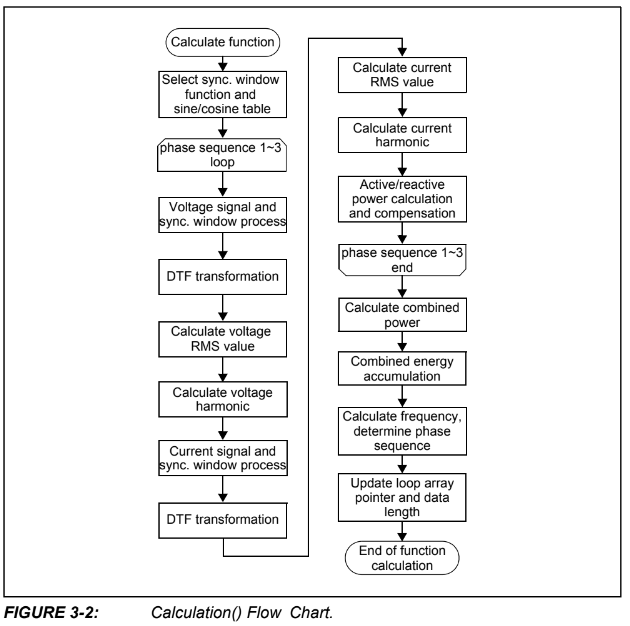


## Hardware:

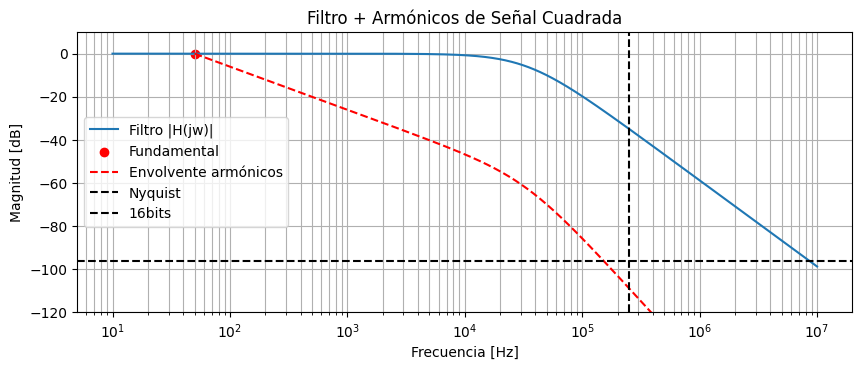

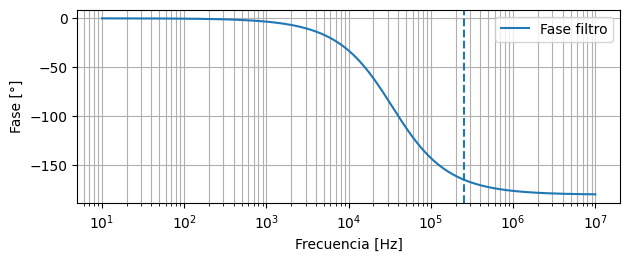

Corte filtro de dos polos
f0 = 33862.75 Hz


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ===================== PARAMETROS =====================
C0 = 47e-9
C1 = C0
R0 = 100
R1 = R0

f0 = 50                  # frecuencia fundamental de la cuadrada
num_harmonics = 250e3/f0  # cantidad de armónicos a mostrar
fs = 500e3                # frecuencia de muestreo (para marcar Nyquist)

# ===================== TRANSFER FUNCTION =====================
def H(jw):
    s = 1j * jw
    return 1 / (C0*C1*R0*R1*s**2 + (C0*R0 + C1*R1)*s + 1)

# ===================== FRECUENCIA =====================
f = np.logspace(1, 7, 1000)  # 1 Hz a 10 kHz
w = 2 * np.pi * f

H_mag = np.abs(H(w))
H_db = 20 * np.log10(H_mag)
H_phase = np.unwrap(np.angle(H(w))) * 180/np.pi  # en grados

# ===================== ARMONICOS CUADRADA =====================
harmonics = np.arange(1, num_harmonics*2, 2)  # solo impares
f_h = harmonics * f0

# amplitud de Fourier de cuadrada
A_h = (4 / (np.pi * harmonics))*(np.pi/4)

# pasar por el filtro
H_h = np.abs(H(2*np.pi*f_h))
A_out = A_h * H_h
A_out_db = 20 * np.log10(A_out)

# ===================== PLOT =====================
plt.figure(figsize=(10,8))

# -------- MAGNITUD --------
plt.subplot(2,1,1)

# respuesta del filtro
plt.semilogx(f, H_db, label="Filtro |H(jw)|")

# --- FUNDAMENTAL ---
#plt.vlines(f_h[0], -120, A_out_db[0], colors='r', linewidth=2)
plt.scatter([f_h[0]], [A_out_db[0]], color='r', label="Fundamental")

# --- ENVOLVENTE (clave) ---
plt.plot(f_h, A_out_db, 'r--', linewidth=1.5, label="Envolvente armónicos")

# Nyquist
plt.axvline(fs/2, linestyle='--', c='k', label="Nyquist")

plt.axhline(-96.3, linestyle='--', c='k', label="16bits")

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Filtro + Armónicos de Señal Cuadrada")
plt.grid(True, which="both")
plt.legend()

plt.ylim([-120, 10])
plt.show()

# -------- FASE --------
plt.subplot(2,1,2)
plt.semilogx(f, H_phase, label="Fase filtro")

plt.axvline(fs/2, linestyle='--')

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [°]")
plt.grid(True, which="both")
plt.legend()

plt.tight_layout()
plt.show()

print("Corte filtro de dos polos")
f0 = 1 / (2 * np.pi * np.sqrt(R0*R1*C0*C1))
print(f"f0 = {f0:.2f} Hz")




Fuente Aislada:

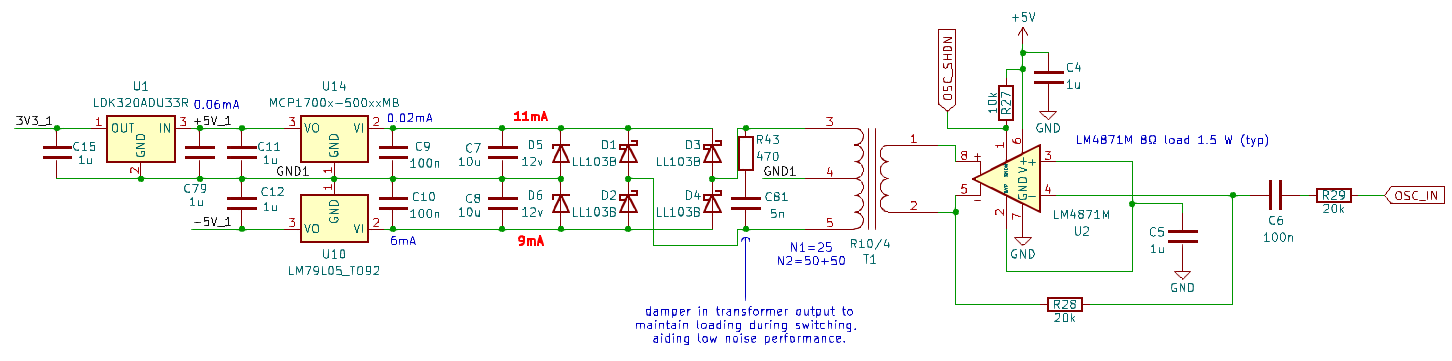

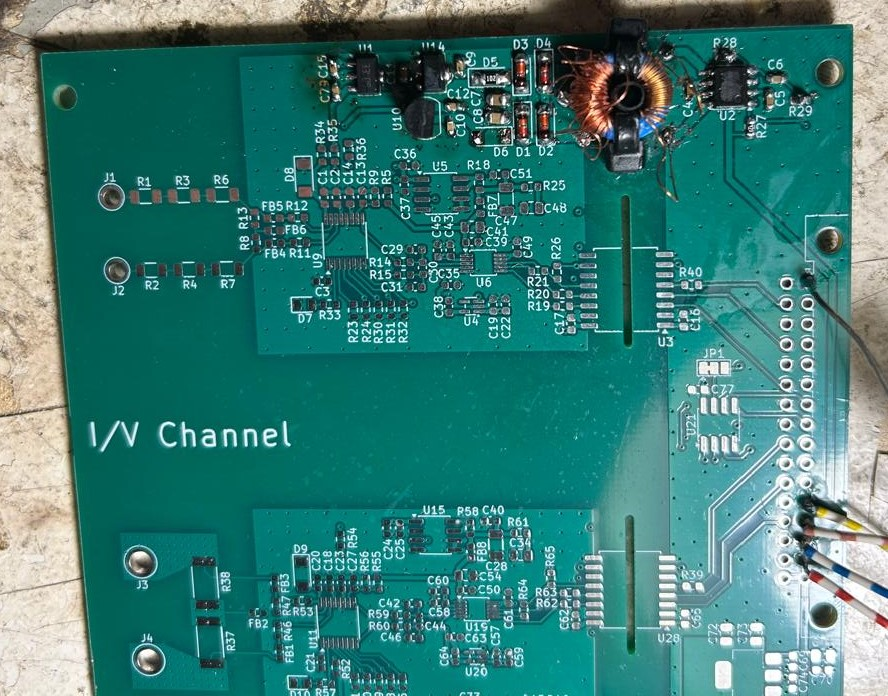

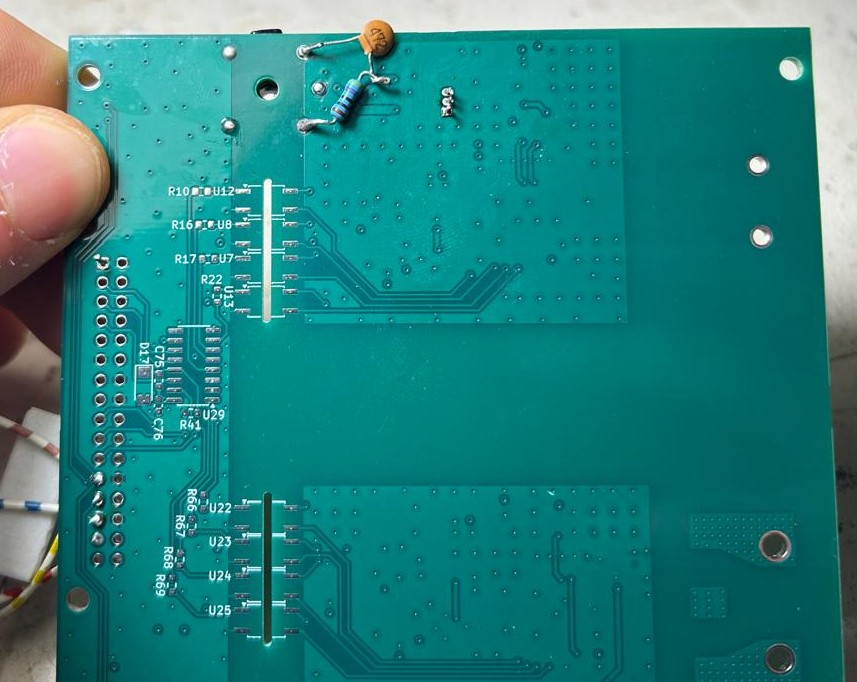

Voltage Divider + PGA + ADC:


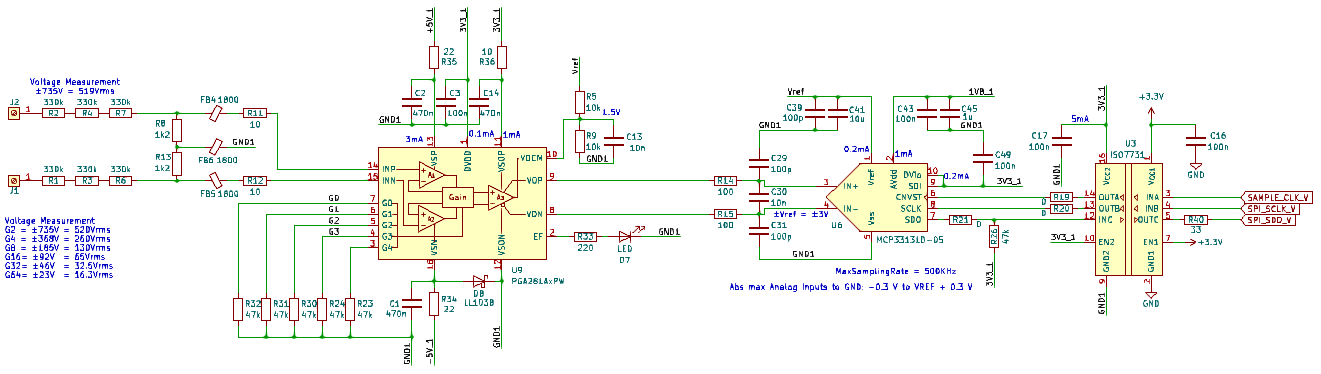

Shunt + PGA + ADC:


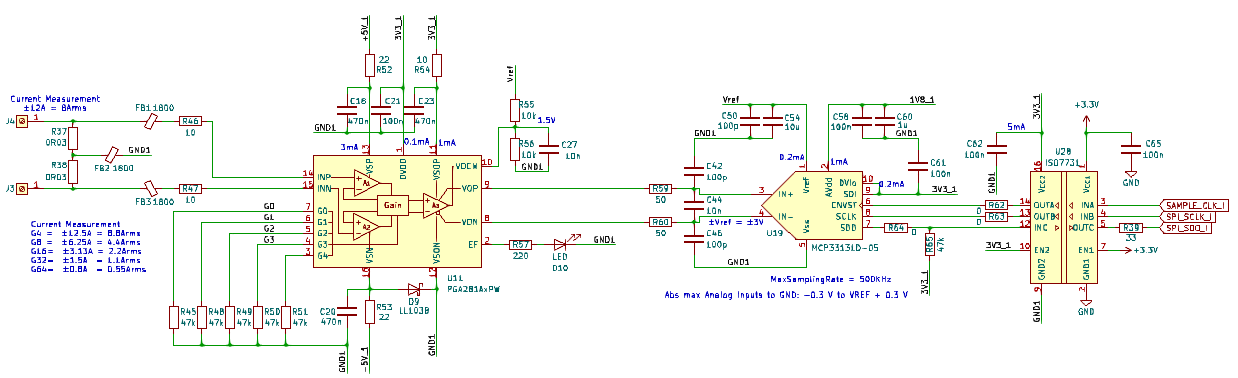

# Compensación de fase para el filtro AA

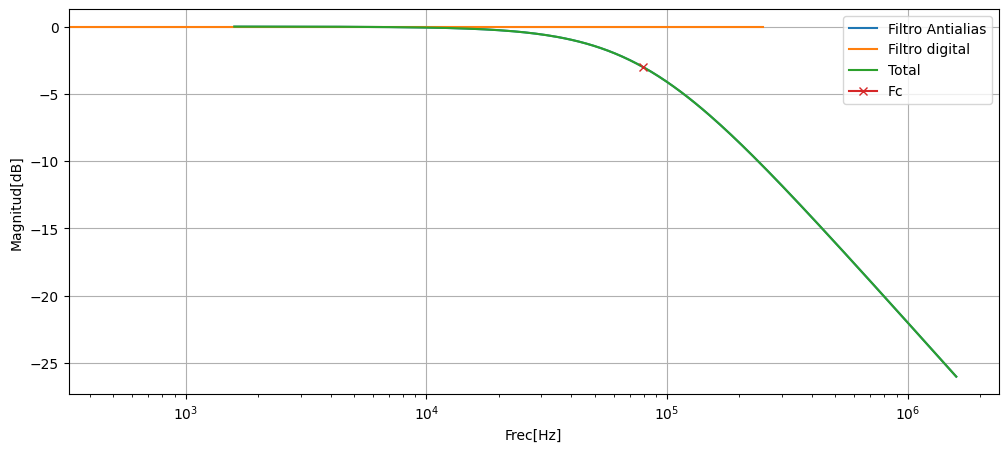

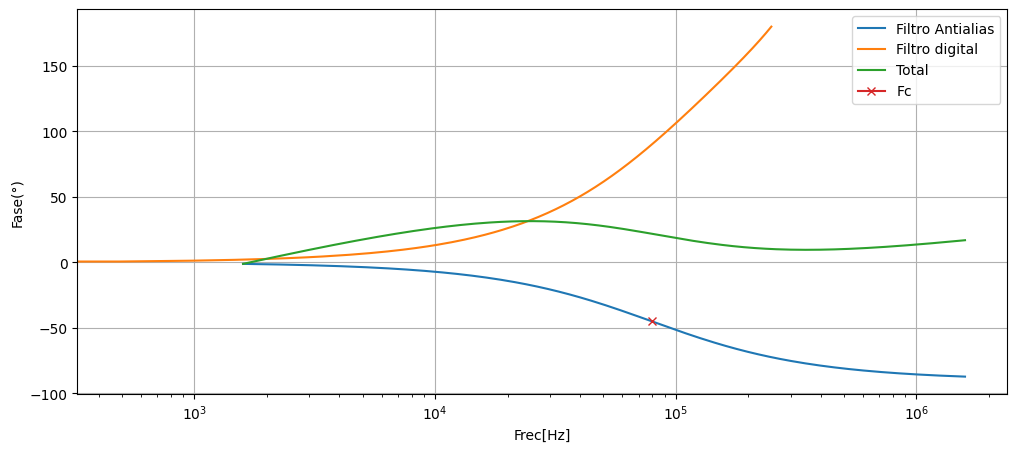

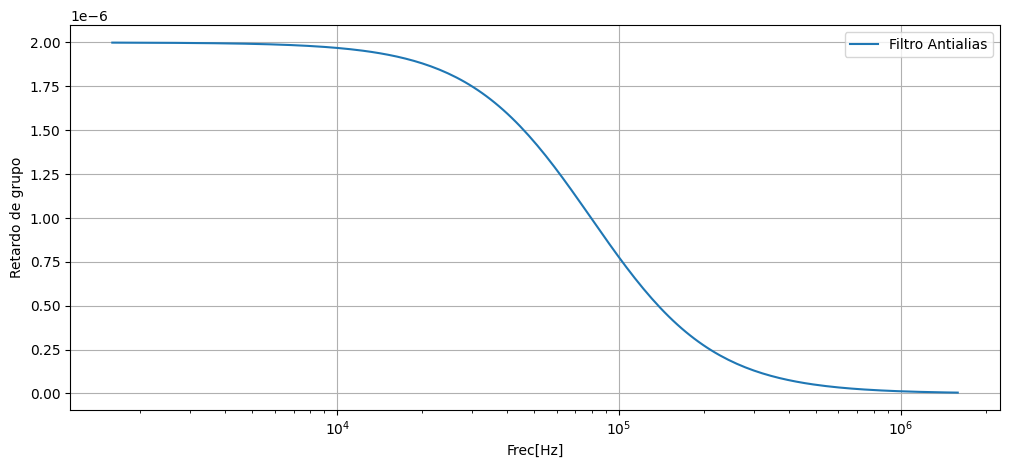

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp

R = 100
C = 20e-9
fs = 500e3

w0 = 1/(R*C)
w, H_FAA = sp.freqs([1], [1/w0, 1])
H_FAA_dB = 20*np.log10(np.abs(H_FAA))
H_FAA_ph = np.degrees(np.angle(H_FAA))
# Using the analytical derivative of the phase
analog_group_delay = (1 / w0) / (1 + (w / w0)**2)

# Compensador de fase como filtro digital:
f0 = w0/(2*np.pi)
alpha = (np.tan((np.pi*f0)/fs)-1)/(np.tan((np.pi*f0)/fs)+1)
a = [alpha, 1.0]
b = [1.0, alpha]
f_z, H_COMP = sp.freqz(b, a, fs=fs)
H_COMP_dB = 20*np.log10(np.abs(H_COMP))
H_COMP_ph = np.degrees(np.angle(H_COMP))

H_CASC = H_FAA*H_COMP[:200]
H_CASC_dB = 20*np.log10(np.abs(H_CASC))
H_CASC_ph = np.degrees(np.angle(H_CASC))


plt.figure(figsize=(12,5))
plt.plot(w/(2*np.pi), H_FAA_dB, label="Filtro Antialias")
plt.plot(f_z, H_COMP_dB, label="Filtro digital")
plt.plot(w/(2*np.pi), H_CASC_dB, label="Total")
plt.plot([w0/(2*np.pi)], [-3], label="Fc", marker="x")
plt.xlabel("Frec[Hz]")
plt.ylabel("Magnitud[dB]")
plt.xscale("log")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(w/(2*np.pi), H_FAA_ph, label="Filtro Antialias")
plt.plot(f_z, H_COMP_ph, label="Filtro digital")
plt.plot(w/(2*np.pi), H_CASC_ph, label="Total")
plt.plot([w0/(2*np.pi)], [-45], label="Fc", marker="x")
plt.xlabel("Frec[Hz]")
plt.ylabel("Fase(°)")
plt.xscale("log")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(w/(2*np.pi), analog_group_delay, label="Filtro Antialias")
#plt.plot(f_z, H_COMP_ph, label="Filtro digital")
#plt.plot(w/(2*np.pi), H_CASC_ph, label="Total")
#plt.plot([w0/(2*np.pi)], [-45], label="Fc", marker="x")
plt.xlabel("Frec[Hz]")
plt.ylabel("Retardo de grupo")
plt.xscale("log")
plt.grid(True)
plt.legend()
plt.show()

# Compensación, IIR orden 2

--- OPTIMIZATION RESULTS ---
Ideal f0: 139548.5 Hz
Ideal Q:  0.5369

Digital Numerator (b):   [0.04397, 0.1898, 1.0]
Digital Denominator (a): [1.0, 0.1898, 0.04397]


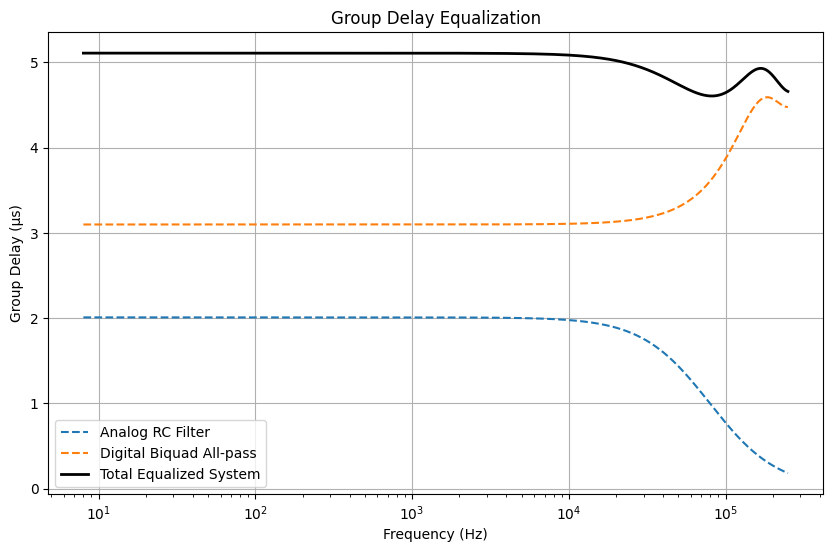

In [1]:
import numpy as np
import scipy.signal as signal
import scipy.optimize as opt
import matplotlib.pyplot as plt

# --- 1. System Parameters ---
fs = 500000       # 500 kHz
R = 100
C = 20.1e-9
w0_analog = 1 / (R * C)

# --- 2. Define the Passband ---
# We optimize for flatness
# Here we start at i think 8Hz was defined by our highpass filter to filter DC and we end at Fs/2 which is 250k
f_pass = np.linspace(8, 250e3, 500) 
w_pass = 2 * np.pi * f_pass

# True analog group delay (in seconds)
analog_gd = (1 / w0_analog) / (1 + (w_pass / w0_analog)**2)

# --- 3. The Objective (Cost) Function ---
def calculate_flatness(params):
    f0, Q = params
    
    # Boundary constraints to keep the math physically possible
    if f0 <= 0 or f0 >= fs/2 or Q <= 0:
        return 1e6  
    
    # 2nd-Order Digital All-Pass Coefficients (Cookbook method)
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)
    
    # b = numerator, a = denominator
    b = [(1 - alpha), -2 * np.cos(w0), (1 + alpha)]
    a = [(1 + alpha), -2 * np.cos(w0), (1 - alpha)]
    
    # Calculate digital group delay
    w_dig, dig_gd_samples = signal.group_delay((b, a), w=f_pass, fs=fs)
    dig_gd = dig_gd_samples / fs  # Convert samples to seconds
    
    # Total delay is the sum of both filters
    total_gd = analog_gd + dig_gd
    
    # We want the flattest line, so we minimize the standard deviation
    return np.std(total_gd)

# --- 4. Run the Optimizer ---
# We give it an initial guess: f0 = 80 kHz, Q = 0.5
initial_guess = [80000, 0.5]
result = opt.minimize(calculate_flatness, initial_guess, method='Nelder-Mead')

best_f0, best_Q = result.x
print(f"--- OPTIMIZATION RESULTS ---")
print(f"Ideal f0: {best_f0:.1f} Hz")
print(f"Ideal Q:  {best_Q:.4f}")

# --- 5. Generate the Final Coefficients ---
w0_opt = 2 * np.pi * best_f0 / fs
alpha_opt = np.sin(w0_opt) / (2 * best_Q)

b_opt = [(1 - alpha_opt), -2 * np.cos(w0_opt), (1 + alpha_opt)]
a_opt = [(1 + alpha_opt), -2 * np.cos(w0_opt), (1 - alpha_opt)]

# Normalize coefficients by a[0] (standard format for IIR filters)
b_opt = [coef / a_opt[0] for coef in b_opt]
a_opt = [coef / a_opt[0] for coef in a_opt]

print(f"\nDigital Numerator (b):   {[round(x, 5) for x in b_opt]}")
print(f"Digital Denominator (a): {[round(x, 5) for x in a_opt]}")

# --- 6. Plot the Results ---
_, dig_gd_samples_opt = signal.group_delay((b_opt, a_opt), w=f_pass, fs=fs)
dig_gd_opt = dig_gd_samples_opt / fs

plt.figure(figsize=(10, 6))
plt.plot(f_pass, analog_gd * 1e6, label="Analog RC Filter", linestyle="--")
plt.plot(f_pass, dig_gd_opt * 1e6, label="Digital Biquad All-pass", linestyle="--")
plt.plot(f_pass, (analog_gd + dig_gd_opt) * 1e6, label="Total Equalized System", color="black", linewidth=2)

plt.title("Group Delay Equalization")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Group Delay (µs)")
plt.xscale("log")
plt.legend()
plt.grid(True)
plt.show()

# Compensación, IIR orden 4

Analog pole frequency: 16931.4 Hz
--- OPTIMIZATION RESULTS ---
Ideal f01: 21519.0 Hz
Ideal Q1:  0.5599
Ideal f02: 31095.1 Hz
Ideal Q2:  0.5368

--- Biquad 1 Coefficients ---
float b1[3] = { 0.0684889f, -0.2318377f, 1.0000000f };
float a1[3] = { 1.0000000f, -0.2318377f, 0.0684889f };

--- Biquad 2 Coefficients ---
float b2[3] = { 0.0730206f, 0.4009573f, 1.0000000f };
float a2[3] = { 1.0000000f, 0.4009573f, 0.0730206f };

Maximum group delay: 44.246 uS


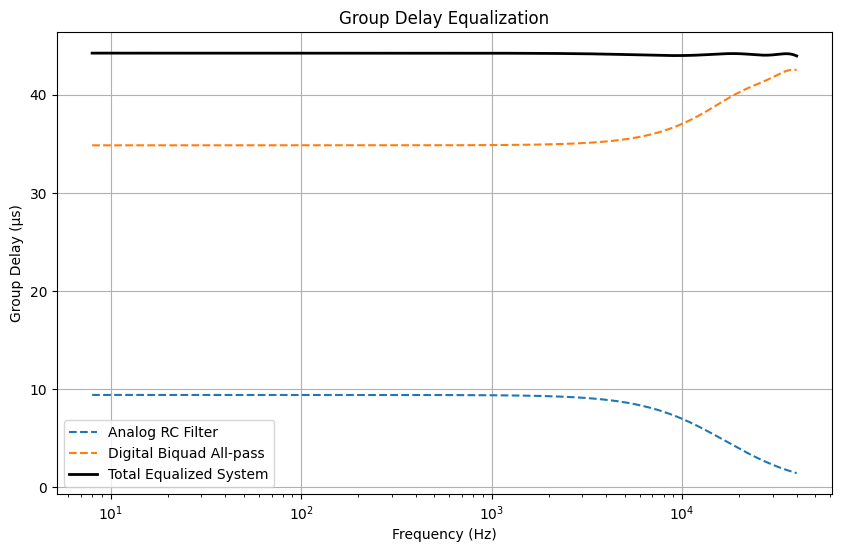

In [10]:
import numpy as np
import scipy.signal as signal
import scipy.optimize as opt
import matplotlib.pyplot as plt

# --- 1. System Parameters ---
fs = 100e3
R = 470
C = 20e-9
w0_analog = 1 / (R * C)
f0 = w0_analog / (2 * np.pi)
print(f"Analog pole frequency: {f0:.1f} Hz")

# --- 2. Define the Passband ---
# We optimize for flatness
# Here we start at i think 8Hz was defined by our highpass filter to filter DC and we end at Fs/2
# Actually nevermind, i shouldn't try to optimize for group delay all the way to the nyquist frecuency 
# cuz its a waste of processing power and theres always gonna be some distorsion
f_pass = np.linspace(8, fs/2 - 0.1*fs, 1024) 
w_pass = 2 * np.pi * f_pass

# True analog group delay (in seconds)
analog_gd = (1 / w0_analog) / (1 + (w_pass / w0_analog)**2)

# --- 3. The Objective (Cost) Function ---
def calculate_flatness(params):
    f01, f02, Q1, Q2 = params
    
    # Boundary constraints to keep the math physically possible
    if f01 <= 0 or f01 >= fs/2 or Q1 <= 0 or f02 <= 0 or f02 >= fs/2 or Q2 <= 0:
        return 1e6  
    
    # 2nd-Order Digital All-Pass Coefficients (Cookbook method)
    w01 = 2 * np.pi * f01 / fs
    alpha1 = np.sin(w01) / (2 * Q1)
    
    # b = numerator, a = denominator
    b1 = [(1 - alpha1), -2 * np.cos(w01), (1 + alpha1)]
    a1 = [(1 + alpha1), -2 * np.cos(w01), (1 - alpha1)]
    
    w02 = 2 * np.pi * f02 / fs
    alpha2 = np.sin(w02) / (2 * Q2)
    
    b2 = [(1 - alpha2), -2 * np.cos(w02), (1 + alpha2)]
    a2 = [(1 + alpha2), -2 * np.cos(w02), (1 - alpha2)]
        
    # Calculate digital group delay
    w_dig1, dig_gd_samples1 = signal.group_delay((b1, a1), w=f_pass, fs=fs)
    w_dig2, dig_gd_samples2 = signal.group_delay((b2, a2), w=f_pass, fs=fs)
    dig_gd_samples = dig_gd_samples1 + dig_gd_samples2 #group delay is additive
    dig_gd = dig_gd_samples / fs  # Convert samples to seconds
    
    # Total delay is the sum of both filters
    total_gd = analog_gd + dig_gd
    
    # We want the flattest line, so we minimize the standard deviation
    return np.std(total_gd)

# --- 4. Run the Optimizer ---
# We give it an initial guess before running the minimization algorithm. I use fractions of f0 cuz wont work if i start with 
# f0 or a frecuency higher than f0. Try it and itll give you negative group delay, its kinda funny.
initial_guess = [f0/4, f0/2, 0.5, 0.75]
result = opt.minimize(calculate_flatness, initial_guess, method='Nelder-Mead')

best_f01, best_f02, best_Q1, best_Q2 = result.x
print(f"--- OPTIMIZATION RESULTS ---")
print(f"Ideal f01: {best_f01:.1f} Hz")
print(f"Ideal Q1:  {best_Q1:.4f}")
print(f"Ideal f02: {best_f02:.1f} Hz")
print(f"Ideal Q2:  {best_Q2:.4f}")


# --- 5. Generate the Final Coefficients ---
# Stage 1 (First Biquad)
w01_opt = 2 * np.pi * best_f01 / fs
alpha1_opt = np.sin(w01_opt) / (2 * best_Q1)

b1_opt = [(1 - alpha1_opt), -2 * np.cos(w01_opt), (1 + alpha1_opt)]
a1_opt = [(1 + alpha1_opt), -2 * np.cos(w01_opt), (1 - alpha1_opt)]

# Normalize Stage 1 coefficients
b1_opt = [coef / a1_opt[0] for coef in b1_opt]
a1_opt = [coef / a1_opt[0] for coef in a1_opt]

# Stage 2 (Second Biquad)
w02_opt = 2 * np.pi * best_f02 / fs
alpha2_opt = np.sin(w02_opt) / (2 * best_Q2)

b2_opt = [(1 - alpha2_opt), -2 * np.cos(w02_opt), (1 + alpha2_opt)]
a2_opt = [(1 + alpha2_opt), -2 * np.cos(w02_opt), (1 - alpha2_opt)]

# Normalize Stage 2 coefficients
b2_opt = [coef / a2_opt[0] for coef in b2_opt]
a2_opt = [coef / a2_opt[0] for coef in a2_opt]

print("\n--- Biquad 1 Coefficients ---")
print(f"float b1[3] = {{ {b1_opt[0]:.7f}f, {b1_opt[1]:.7f}f, {b1_opt[2]:.7f}f }};")
print(f"float a1[3] = {{ {a1_opt[0]:.7f}f, {a1_opt[1]:.7f}f, {a1_opt[2]:.7f}f }};")

print("\n--- Biquad 2 Coefficients ---")
print(f"float b2[3] = {{ {b2_opt[0]:.7f}f, {b2_opt[1]:.7f}f, {b2_opt[2]:.7f}f }};")
print(f"float a2[3] = {{ {a2_opt[0]:.7f}f, {a2_opt[1]:.7f}f, {a2_opt[2]:.7f}f }};")

# Combine both stages into a single 4th-order system using convolution
b_combined = np.convolve(b1_opt, b2_opt)
a_combined = np.convolve(a1_opt, a2_opt)

# --- 6. Plot the Results ---
# Calculate the total group delay of the cascaded digital system
_, dig_gd_samples_opt = signal.group_delay((b_combined, a_combined), w=f_pass, fs=fs)
dig_gd_opt = dig_gd_samples_opt / fs
plt.figure(figsize=(10, 6))
plt.plot(f_pass, analog_gd * 1e6, label="Analog RC Filter", linestyle="--")
plt.plot(f_pass, dig_gd_opt * 1e6, label="Digital Biquad All-pass", linestyle="--")
plt.plot(f_pass, (analog_gd + dig_gd_opt) * 1e6, label="Total Equalized System", color="black", linewidth=2)

print(f"\nMaximum group delay: {round(np.max(analog_gd + dig_gd_opt)*1e6, 3)} uS")

plt.title("Group Delay Equalization")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Group Delay (µs)")
plt.xscale("log")
plt.legend()
plt.grid(True)
plt.show()